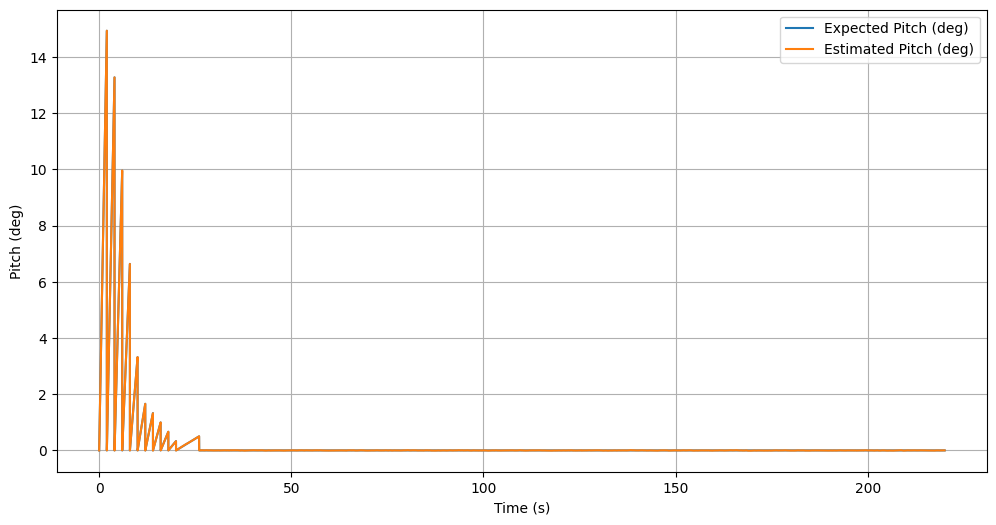

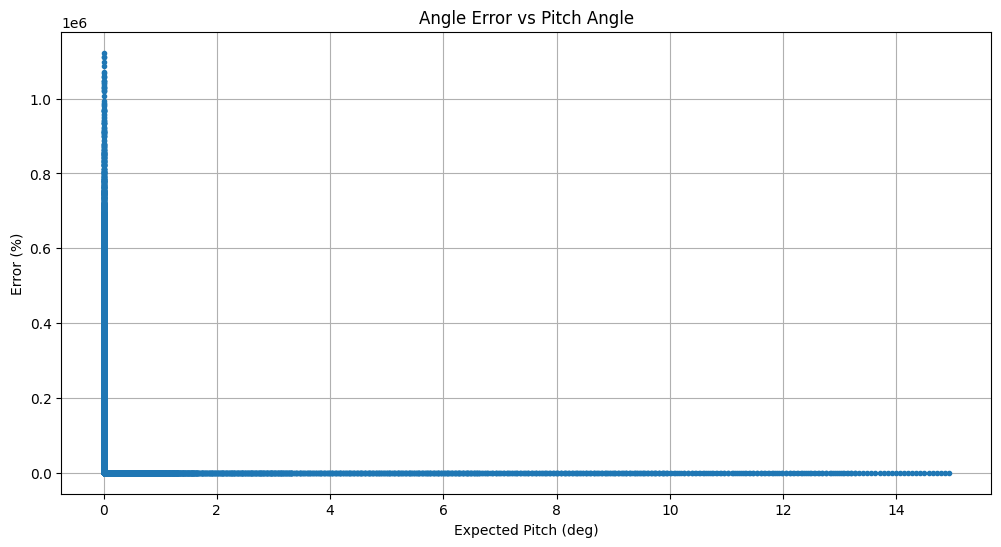

In [5]:
import numpy as np
import matplotlib.pyplot as plt
 
# Simulation parameters
fs = 104  # Hz
dt = 1/fs
angles = [45,40,30,20,10,5,4,3,2,1,0.5]
T = len(angles)*20  # total time in seconds
t = np.arange(0, T, dt)
 
# Sensor noise (from datasheet)
gyro_noise_density = 0.005  # deg/s/√Hz
accel_noise_density = 60e-6  # g/√Hz
g = 9.80665
 
# Convert accel noise density to angle noise density (small angle approx)
Sa_deg = accel_noise_density * (180/np.pi)  # deg/√Hz
Sg_deg = gyro_noise_density  # deg/s/√Hz
 
# %%
# Define a ground truth sequence: rest -> pitch up to 45° -> rest -> yaw rotate 90° -> rest
angles_pitch = np.zeros_like(t)
angles_yaw = np.zeros_like(t)

for idx, angle in enumerate(angles):
    # Create pitch motion (altitude change)
    pitch_start, pitch_end = 2*idx, 2*idx+6  # seconds
    pitch_angle = angle  # deg
    mask = (t >= pitch_start) & (t <= pitch_end)
    angles_pitch[mask] = np.linspace(0, pitch_angle, mask.sum())
    
    # Create yaw motion (azimuth change)
    yaw_start, yaw_end = 10*idx, 10*idx+14
    yaw_angle = angle  # deg
    mask = (t >= yaw_start) & (t <= yaw_end)
    angles_yaw[mask] = np.linspace(0, yaw_angle, mask.sum())
 
# Combine ground truth
angles_truth = np.vstack([angles_pitch, angles_yaw]).T  # [N, 2]
 
# %%
# Generate synthetic accelerometer and gyro readings from ground truth
 
def angles_to_accel(pitch_deg):
    # Only simulate pitch: accel measures tilt from gravity
    pitch_rad = np.deg2rad(pitch_deg)
    ax = np.sin(pitch_rad) * g
    ay = 0
    az = np.cos(pitch_rad) * g
    return np.array([ax, ay, az])
 
def angles_to_gyro(prev_angle, curr_angle):
    # Gyro measures angular velocity (deg/s)
    return (curr_angle - prev_angle) / dt
 
# Simulate
accel_data = []
gyro_data = []
for i in range(len(t)):
    pitch, yaw = angles_truth[i]
    # accel only sensitive to pitch (simplified)
    accel = angles_to_accel(pitch)
    # add accel noise
    accel += np.random.normal(0, accel_noise_density * g * np.sqrt(fs/2), 3)
    accel_data.append(accel)
 
    if i > 0:
        gyro_pitch = angles_to_gyro(angles_truth[i-1,0], pitch)
        gyro_yaw = angles_to_gyro(angles_truth[i-1,1], yaw)
    else:
        gyro_pitch, gyro_yaw = 0, 0
    # add gyro noise
    gyro_pitch += np.random.normal(0, Sg_deg*np.sqrt(fs/2))
    gyro_yaw += np.random.normal(0, Sg_deg*np.sqrt(fs/2))
    gyro_data.append([gyro_pitch, gyro_yaw])
 
accel_data = np.array(accel_data)
gyro_data = np.array(gyro_data)
 
# %%
# Complementary filter (for pitch only, since yaw has no accel reference)
fc = 0.23  # Hz cutoff
alpha = 1 - (dt * 2 * np.pi * fc)  # simple discrete approx
 
pitch_est = np.zeros_like(t)
for i in range(1, len(t)):
    gyro_rate = gyro_data[i,0]  # deg/s
    accel_angle = np.rad2deg(np.arctan2(accel_data[i,0], accel_data[i,2]))
    pitch_est[i] = alpha*(pitch_est[i-1] + gyro_rate*dt) + (1-alpha)*accel_angle
 
# %%
# Metrics: error %, DPS
expected_pitch = angles_truth[:,0]
error = np.abs(pitch_est - expected_pitch)
error_percent = (error / np.maximum(expected_pitch, 1e-6)) * 100  # avoid div0
dps = np.gradient(expected_pitch, dt)
 
# %%
# Plot results
plt.figure(figsize=(12,6))
plt.plot(t, expected_pitch, label="Expected Pitch (deg)")
plt.plot(t, pitch_est, label="Estimated Pitch (deg)")
plt.xlabel("Time (s)")
plt.ylabel("Pitch (deg)")
plt.legend()
plt.grid()
plt.show()
 
plt.figure(figsize=(12,6))
plt.plot(expected_pitch, error_percent, ".")
plt.xlabel("Expected Pitch (deg)")
plt.ylabel("Error (%)")
plt.title("Angle Error vs Pitch Angle")
plt.grid()
plt.show()

In [6]:
def segmentation_gaps(df):
    # Detect time gaps for segmentation
    gap_threshold = 5.0  # seconds
    timestamps = df["timestamp"].values
    gaps = np.where(np.abs(np.diff(timestamps)) > gap_threshold)[0]

    # Create segment boundaries
    segment_bounds = []
    start = 0
    for gap_idx in gaps:
        segment_bounds.append((start, gap_idx + 1))
        start = gap_idx + 1
    segment_bounds.append((start, len(df)))

    print(f"Found {len(segment_bounds)} segments:")
    for i, (start, end) in enumerate(segment_bounds):
        duration = df.iloc[end-1]['timestamp'] - df.iloc[start]['timestamp']
        print(f"  Segment {i}: samples {start}-{end-1}, duration {duration:.1f}s")

    # Map to test configuration if available
    segments = []
    for i, (start, end) in enumerate(segment_bounds):
        segment_data = df.iloc[start:end].copy()
        segments.append({
            'test_id': i,
            'data': segment_data.reset_index(),
            'start_idx': start,
            'end_idx': end
        })
    return segments

In [7]:
import pandas as pd
from motion_estimator import MotionEstimator
 
df = pd.read_csv("raw_data_output_altitude.csv")
required_cols = ["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Convert to numeric
for col in required_cols[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Drop rows with NaN values in required columns
df = df.dropna(subset=required_cols)
# Convert from EDN (East-Down-North) to NED (North-East-Down) coordinate system
# This ensures Az (Z-axis) is aligned with gravity vector
# EDN -> NED transformation:
# X_EDN -> Y_NED (East -> East)  
# Y_EDN -> -Z_NED (Down -> -Down)
# Z_EDN -> X_NED (North -> North)

# Accelerometer conversion
accel_x_ned = df["accel_z"].copy()  # North (Z_EDN -> X_NED)
accel_y_ned = df["accel_x"].copy()  # East (X_EDN -> Y_NED)  
accel_z_ned = -df["accel_y"].copy() # Down (Y_EDN -> -Z_NED)

df["accel_x"] = accel_x_ned
df["accel_y"] = accel_y_ned
df["accel_z"] = accel_z_ned

# Gyroscope conversion (same transformation)
gyro_x_ned = df["gyro_z"].copy()  # North
gyro_y_ned = df["gyro_x"].copy()  # East
gyro_z_ned = -df["gyro_y"].copy() # Down

df["gyro_x"] = gyro_x_ned
df["gyro_y"] = gyro_y_ned
df["gyro_z"] = gyro_z_ned

segments = segmentation_gaps(df)

# # Process first 5 seconds of data (104 Hz * 5 sec = 520 samples) to get reference
# for segment in segments:
#     test_id, data, start_idx, end_idx = segment.values()
#     for i in range(start_idx, end_idx):
#             _ref_pitch_deg = []
            

#         update(
#             [data["accel_x"][i], data["accel_y"][i], data["accel_z"][i]],
#             [data["gyro_x"][i], data["gyro_y"][i], data["gyro_z"][i]],
#             data["timestamp"][i]
#         )
#         _ref_pitch_deg.append(_prev_pitch_deg)
#         _ref_roll_deg.append(_prev_roll_deg)
#         _ref_yaw_deg.append(_prev_yaw_deg)
#     printState()

Found 12 segments:
  Segment 0: samples 0-7068, duration 64.0s
  Segment 1: samples 7069-14048, duration 63.1s
  Segment 2: samples 14049-21043, duration 63.2s
  Segment 3: samples 21044-24877, duration 34.6s
  Segment 4: samples 24878-28643, duration 34.1s
  Segment 5: samples 28644-32543, duration 35.1s
  Segment 6: samples 32544-36583, duration 36.4s
  Segment 7: samples 36584-40743, duration 37.5s
  Segment 8: samples 40744-44419, duration 33.1s
  Segment 9: samples 44420-47983, duration 32.2s
  Segment 10: samples 47984-51803, duration 34.4s
  Segment 11: samples 51804-55614, duration 34.4s


In [ ]:
estimator = MotionEstimator()
 
# Process first segment
seg = segments[0]["data"]
outputs = []
for segment in segments:
    test_id, data, start_idx, end_idx = segment.values()
    segment_result = {}
    for i, row in seg.iterrows():
        accel_raw = [row["accel_x"], row["accel_y"], row["accel_z"]]  # mg
        gyro_raw = [row["gyro_x"], row["gyro_y"], row["gyro_z"]]      # dps
        ts = row["timestamp"]
        output = estimator.update(accel_raw, gyro_raw, ts)
        segment_result = {'test_id': test_id}
        segment_result.update(output)
        outputs.append(segment_result)

# Based on the test_id, we know what angle was changed at what time. (e.g., test 0 has no angle change)
out_df = pd.DataFrame(outputs)
print(out_df.head())

   test_id    yaw_deg  pitch_deg   roll_deg  timestamp
0        0   9.523667  -4.542216  12.315268      0.743
1        0  17.929202  -9.050495  21.814222      0.743
2        0  25.476013 -13.665760  29.760735      0.743
3        0  32.363322 -18.186747  36.502021      0.743
4        0  38.744135 -22.615864  42.151782      0.743


<Axes: title={'center': 't'}, ylabel='deg'>

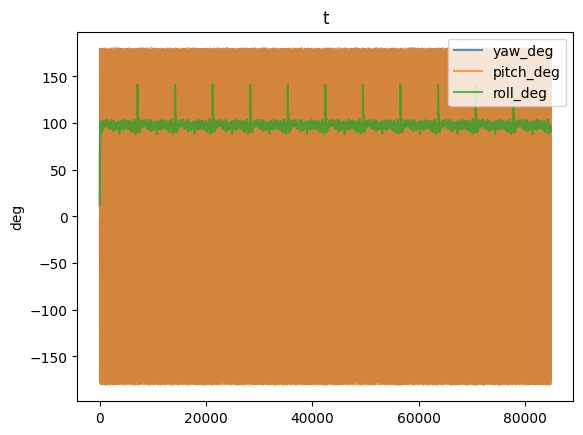

In [15]:
out_df.iloc[:, 1:-1].plot(ylabel='deg', title='t', alpha=0.75)

Running synthetic tests...
Testing: pitch_small_slow (max 0.5 dps)
Testing: pitch_small_fast (max 2.0 dps)
Testing: pitch_medium_slow (max 2.5 dps)
Testing: pitch_medium_fast (max 10.0 dps)
Testing: pitch_large_slow (max 5.6 dps)
Testing: pitch_large_fast (max 22.5 dps)
Testing: yaw_small (max 2.5 dps)
Testing: yaw_large (max 22.5 dps)

=== Test Results Summary ===
            scenario  angle_magnitude    max_dps        rmse  settling_time
0   pitch_small_slow              1.0   1.506508   76.381890            inf
1   pitch_small_fast              1.0   6.068843   65.172956            inf
2  pitch_medium_slow             10.0   7.517156   90.229893            inf
3  pitch_medium_fast             10.0  30.231479   86.306641            inf
4   pitch_large_slow             45.0  16.894793  150.386635            inf
5   pitch_large_fast             45.0  67.792870  158.868195            inf
6          yaw_small              5.0   7.532541    1.738222            0.0
7          yaw_large    

C:\Users\mfocka\AppData\Local\Temp\ipykernel_39288\856683315.py:194: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  error_map = df.pivot_table(


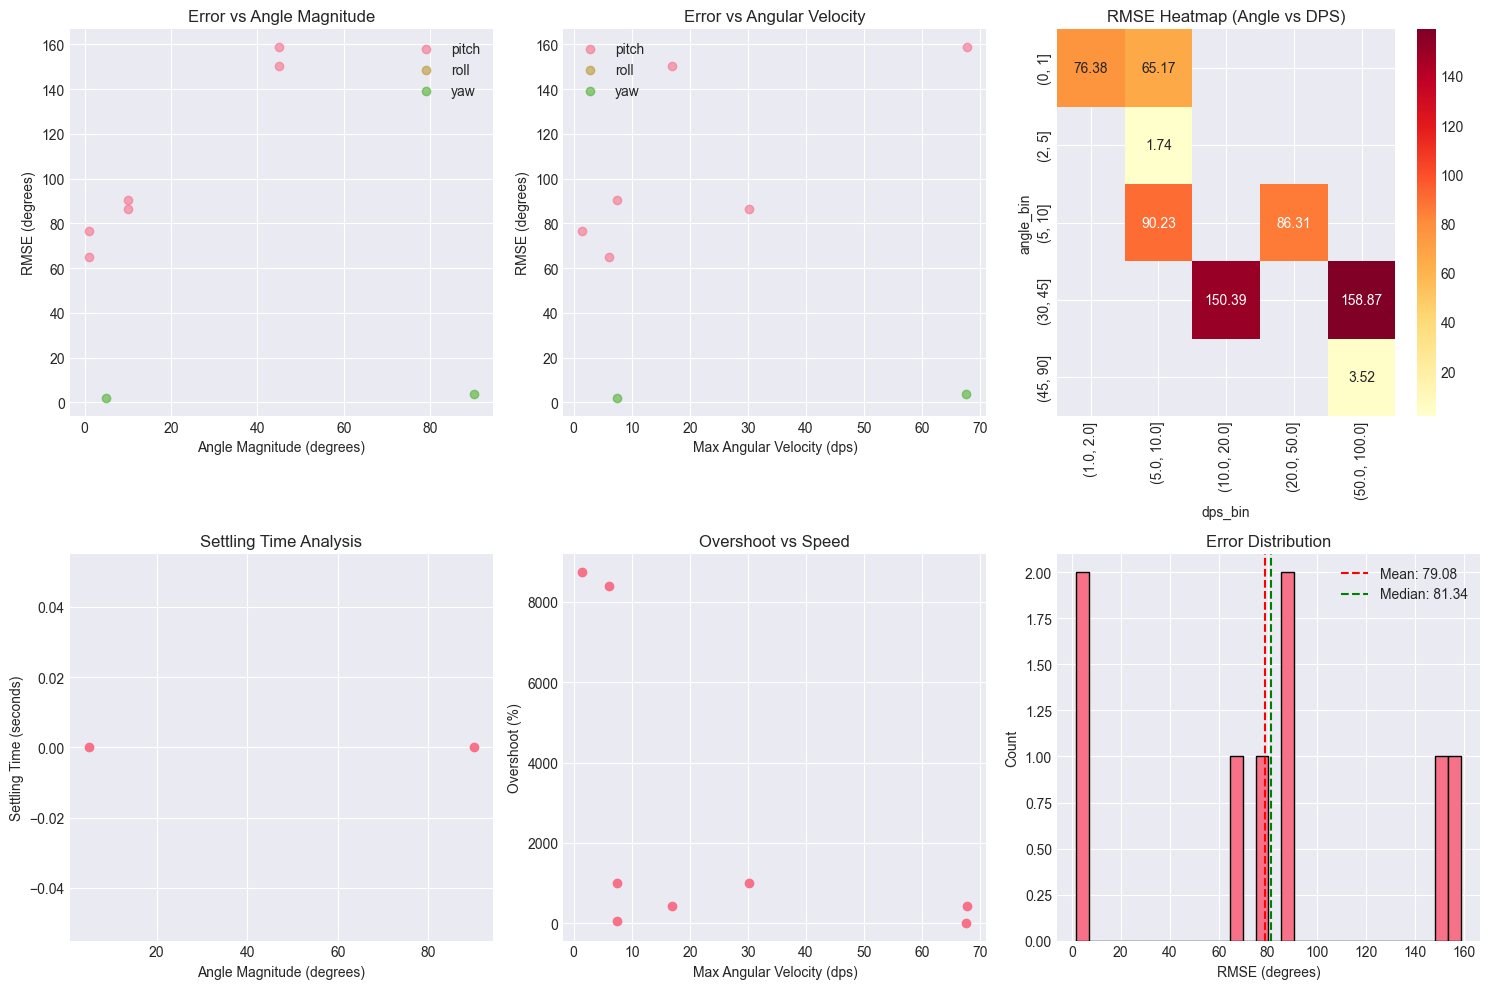


=== Reliability Ranges ===
ACCEPTABLE:
  RMSE ≤ 2.0°
  Angles: 5.0° - 5.0°
  DPS: 7.5 - 7.5 dps
POOR:
  RMSE ≤ 5.0°
  Angles: 5.0° - 90.0°
  DPS: 7.5 - 67.7 dps


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import seaborn as sns
from scipy import signal
from motion_estimator import MotionEstimator

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

@dataclass
class TestScenario:
    """Defines a test scenario with specific motion parameters"""
    name: str
    angle_deg: float  # Target angle
    duration_s: float  # Time to reach angle
    hold_time_s: float  # Time to hold at angle
    axis: str  # 'pitch', 'roll', or 'yaw'
    
    @property
    def max_dps(self) -> float:
        """Calculate max angular velocity for this scenario"""
        return abs(self.angle_deg / self.duration_s) if self.duration_s > 0 else 0

class IMUSimulator:
    """Enhanced IMU data simulator with realistic noise and motion profiles"""
    
    def __init__(self, fs: float = 104):
        self.fs = fs
        self.dt = 1/fs
        self.g = 9.80665
        
        # ISM330DHCX noise specifications
        self.gyro_noise_density = 0.005  # deg/s/√Hz
        self.accel_noise_density = 60e-6  # g/√Hz
        
        # Additional realistic effects
        self.gyro_bias_instability = 0.01  # deg/s
        self.accel_bias_instability = 0.001  # g
        
    def generate_motion_profile(self, scenario: TestScenario, 
                               start_time: float = 0) -> Tuple[np.ndarray, np.ndarray]:
        """Generate smooth motion profile using S-curve acceleration"""
        # Total time for this scenario
        total_time = scenario.duration_s + scenario.hold_time_s
        t = np.arange(0, total_time, self.dt) + start_time
        
        # S-curve profile for smooth acceleration/deceleration
        angles = np.zeros_like(t)
        
        # Ramp up phase
        ramp_samples = int(scenario.duration_s * self.fs)
        if ramp_samples > 0:
            # Use sigmoid for smooth acceleration
            x = np.linspace(-6, 6, ramp_samples)
            sigmoid = 1 / (1 + np.exp(-x))
            angles[:ramp_samples] = scenario.angle_deg * sigmoid
        
        # Hold phase
        angles[ramp_samples:] = scenario.angle_deg
        
        # Calculate angular velocity (with smoothing)
        angular_velocity = np.gradient(angles, self.dt)
        angular_velocity = signal.savgol_filter(angular_velocity, 11, 3) if len(angular_velocity) > 11 else angular_velocity
        
        return t, angles, angular_velocity
    
    def angles_to_imu(self, pitch: np.ndarray, roll: np.ndarray, 
                      yaw: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Convert angles to IMU readings with realistic noise"""
        n = len(pitch)
        accel_data = np.zeros((n, 3))
        gyro_data = np.zeros((n, 3))
        
        # Add slow-varying bias
        gyro_bias = np.cumsum(np.random.randn(n, 3) * self.gyro_bias_instability * np.sqrt(self.dt), axis=0)
        accel_bias = np.cumsum(np.random.randn(n, 3) * self.accel_bias_instability * np.sqrt(self.dt), axis=0)
        
        for i in range(n):
            # Accelerometer measures gravity vector rotation
            pitch_rad = np.deg2rad(pitch[i])
            roll_rad = np.deg2rad(roll[i])
            
            # Rotation matrix effects on gravity
            accel_data[i, 0] = -np.sin(pitch_rad) * self.g
            accel_data[i, 1] = np.sin(roll_rad) * np.cos(pitch_rad) * self.g
            accel_data[i, 2] = np.cos(roll_rad) * np.cos(pitch_rad) * self.g
            
            # Add noise and bias
            accel_noise = np.random.randn(3) * self.accel_noise_density * self.g * np.sqrt(self.fs/2)
            accel_data[i] += accel_noise + accel_bias[i]
            
            # Gyroscope measures angular velocity
            if i > 0:
                gyro_data[i, 0] = (pitch[i] - pitch[i-1]) / self.dt
                gyro_data[i, 1] = (roll[i] - roll[i-1]) / self.dt
                gyro_data[i, 2] = (yaw[i] - yaw[i-1]) / self.dt
            
            # Add noise and bias
            gyro_noise = np.random.randn(3) * self.gyro_noise_density * np.sqrt(self.fs/2)
            gyro_data[i] += gyro_noise + gyro_bias[i]
        
        # Convert to sensor units (mg and dps)
        accel_data_mg = accel_data * 1000 / self.g  # Convert to mg
        gyro_data_dps = gyro_data  # Already in dps
        
        return accel_data_mg, gyro_data_dps

class ErrorAnalyzer:
    """Comprehensive error analysis for motion estimation"""
    
    def __init__(self):
        self.results = []
        
    def analyze_segment(self, ground_truth: np.ndarray, estimated: np.ndarray,
                       timestamps: np.ndarray, segment_info: Dict) -> Dict:
        """Analyze errors for a single segment"""
        
        # Basic error metrics
        error = estimated - ground_truth
        abs_error = np.abs(error)
        
        # Calculate DPS from ground truth
        dps = np.gradient(ground_truth, timestamps[1] - timestamps[0])
        
        # Statistics
        metrics = {
            'scenario': segment_info.get('scenario', 'Unknown'),
            'angle_magnitude': segment_info.get('angle_deg', 0),
            'max_dps': np.max(np.abs(dps)),
            'mean_dps': np.mean(np.abs(dps)),
            
            # Error metrics
            'mean_error': np.mean(error),
            'std_error': np.std(error),
            'rmse': np.sqrt(np.mean(error**2)),
            'max_error': np.max(abs_error),
            'percentile_95': np.percentile(abs_error, 95),
            
            # Time-based metrics
            'settling_time': self._calculate_settling_time(error, threshold=0.5),
            'overshoot': self._calculate_overshoot(ground_truth, estimated),
            
            # Frequency domain analysis
            'noise_power': self._calculate_noise_power(error),
        }
        
        # Store for later analysis
        self.results.append(metrics)
        return metrics
    
    def _calculate_settling_time(self, error: np.ndarray, threshold: float) -> float:
        """Find time to settle within threshold degrees"""
        settled = np.where(np.abs(error) < threshold)[0]
        if len(settled) > 0:
            # Find first continuous settled region
            diffs = np.diff(settled)
            breaks = np.where(diffs > 1)[0]
            if len(breaks) > 0:
                return settled[breaks[0]] / 104  # Convert to seconds
            return settled[0] / 104
        return np.inf
    
    def _calculate_overshoot(self, target: np.ndarray, actual: np.ndarray) -> float:
        """Calculate maximum overshoot percentage"""
        if np.max(np.abs(target)) == 0:
            return 0
        overshoot = np.max(np.abs(actual - target)) / np.max(np.abs(target))
        return overshoot * 100
    
    def _calculate_noise_power(self, error: np.ndarray) -> float:
        """Calculate noise power using FFT"""
        if len(error) < 10:
            return 0
        fft = np.fft.fft(error)
        power = np.abs(fft)**2
        return np.mean(power[len(power)//4:])  # High-frequency component
    
    def create_error_map(self) -> pd.DataFrame:
        """Create error map indexed by angle and DPS"""
        df = pd.DataFrame(self.results)
        
        # Bin angles and DPS for grouping
        angle_bins = [0, 1, 2, 5, 10, 20, 30, 45, 90]
        dps_bins = [0, 0.5, 1, 2, 5, 10, 20, 50, 100]
        
        df['angle_bin'] = pd.cut(df['angle_magnitude'], bins=angle_bins)
        df['dps_bin'] = pd.cut(df['max_dps'], bins=dps_bins)
        
        # Create pivot table for RMSE
        error_map = df.pivot_table(
            values='rmse',
            index='angle_bin',
            columns='dps_bin',
            aggfunc='mean'
        )
        
        return error_map

class MotionEstimatorTester:
    """Main test orchestrator"""
    
    def __init__(self, estimator: Optional[MotionEstimator] = None):
        self.estimator = estimator or MotionEstimator()
        self.simulator = IMUSimulator()
        self.analyzer = ErrorAnalyzer()
        
    def create_test_matrix(self) -> List[TestScenario]:
        """Create comprehensive test scenarios"""
        scenarios = []
        
        # Test different angle magnitudes
        angles = [0.5, 1, 2, 3, 4, 5, 10, 20, 30, 40, 45]
        
        # Test different speeds (duration to reach angle)
        durations = [0.5, 1.0, 2.0, 4.0, 8.0]  # Fast to slow
        
        for angle in angles:
            for duration in durations:
                # Test each axis
                for axis in ['pitch', 'roll', 'yaw']:
                    scenarios.append(TestScenario(
                        name=f"{axis}_{angle}deg_{duration}s",
                        angle_deg=angle,
                        duration_s=duration,
                        hold_time_s=2.0,
                        axis=axis
                    ))
        
        return scenarios
    
    def run_synthetic_tests(self, scenarios: Optional[List[TestScenario]] = None) -> pd.DataFrame:
        """Run tests with synthetic data"""
        if scenarios is None:
            scenarios = self.create_test_matrix()
        
        results = []
        current_time = 0
        
        for scenario in scenarios:
            print(f"Testing: {scenario.name} (max {scenario.max_dps:.1f} dps)")
            
            # Generate motion profile
            t, angles, dps = self.simulator.generate_motion_profile(scenario, current_time)
            
            # Initialize angles
            pitch = np.zeros_like(t)
            roll = np.zeros_like(t)
            yaw = np.zeros_like(t)
            
            # Set the appropriate axis
            if scenario.axis == 'pitch':
                pitch = angles
            elif scenario.axis == 'roll':
                roll = angles
            else:
                yaw = angles
            
            # Generate IMU data
            accel_mg, gyro_dps = self.simulator.angles_to_imu(pitch, roll, yaw)
            
            # Reset estimator for each scenario
            self.estimator = MotionEstimator()
            
            # Process through estimator
            estimated_angles = []
            for i in range(len(t)):
                result = self.estimator.update(
                    accel_mg[i].tolist(),
                    gyro_dps[i].tolist(),
                    t[i]
                )
                estimated_angles.append(result[f"{scenario.axis}_deg"])
            
            estimated_angles = np.array(estimated_angles)
            
            # Analyze errors
            segment_info = {
                'scenario': scenario.name,
                'angle_deg': scenario.angle_deg,
                'axis': scenario.axis
            }
            
            metrics = self.analyzer.analyze_segment(
                angles, estimated_angles, t, segment_info
            )
            results.append(metrics)
            
            current_time = t[-1] + 1.0  # Add gap between scenarios
        
        return pd.DataFrame(results)
    
    def visualize_results(self, results_df: pd.DataFrame):
        """Create comprehensive visualization of test results"""
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. RMSE vs Angle magnitude
        ax = axes[0, 0]
        for axis in ['pitch', 'roll', 'yaw']:
            mask = results_df['scenario'].str.contains(axis)
            data = results_df[mask]
            ax.scatter(data['angle_magnitude'], data['rmse'], label=axis, alpha=0.6)
        ax.set_xlabel('Angle Magnitude (degrees)')
        ax.set_ylabel('RMSE (degrees)')
        ax.set_title('Error vs Angle Magnitude')
        ax.legend()
        ax.grid(True)
        
        # 2. RMSE vs DPS
        ax = axes[0, 1]
        for axis in ['pitch', 'roll', 'yaw']:
            mask = results_df['scenario'].str.contains(axis)
            data = results_df[mask]
            ax.scatter(data['max_dps'], data['rmse'], label=axis, alpha=0.6)
        ax.set_xlabel('Max Angular Velocity (dps)')
        ax.set_ylabel('RMSE (degrees)')
        ax.set_title('Error vs Angular Velocity')
        ax.legend()
        ax.grid(True)
        
        # 3. Error heatmap
        ax = axes[0, 2]
        error_map = self.analyzer.create_error_map()
        sns.heatmap(error_map, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
        ax.set_title('RMSE Heatmap (Angle vs DPS)')
        
        # 4. Settling time analysis
        ax = axes[1, 0]
        ax.scatter(results_df['angle_magnitude'], results_df['settling_time'])
        ax.set_xlabel('Angle Magnitude (degrees)')
        ax.set_ylabel('Settling Time (seconds)')
        ax.set_title('Settling Time Analysis')
        ax.grid(True)
        
        # 5. Overshoot analysis
        ax = axes[1, 1]
        ax.scatter(results_df['max_dps'], results_df['overshoot'])
        ax.set_xlabel('Max Angular Velocity (dps)')
        ax.set_ylabel('Overshoot (%)')
        ax.set_title('Overshoot vs Speed')
        ax.grid(True)
        
        # 6. Error distribution
        ax = axes[1, 2]
        ax.hist(results_df['rmse'], bins=30, edgecolor='black')
        ax.set_xlabel('RMSE (degrees)')
        ax.set_ylabel('Count')
        ax.set_title('Error Distribution')
        ax.axvline(results_df['rmse'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["rmse"].mean():.2f}')
        ax.axvline(results_df['rmse'].median(), color='green', linestyle='--', label=f'Median: {results_df["rmse"].median():.2f}')
        ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    def generate_reliability_ranges(self, results_df: pd.DataFrame) -> Dict:
        """Generate reliability ranges based on test results"""
        
        reliability_ranges = {
            'excellent': {'rmse': 0.5, 'angles': [], 'dps': []},
            'good': {'rmse': 1.0, 'angles': [], 'dps': []},
            'acceptable': {'rmse': 2.0, 'angles': [], 'dps': []},
            'poor': {'rmse': 5.0, 'angles': [], 'dps': []}
        }
        
        for level, config in reliability_ranges.items():
            mask = results_df['rmse'] <= config['rmse']
            if mask.any():
                config['angles'] = [
                    results_df[mask]['angle_magnitude'].min(),
                    results_df[mask]['angle_magnitude'].max()
                ]
                config['dps'] = [
                    results_df[mask]['max_dps'].min(),
                    results_df[mask]['max_dps'].max()
                ]
        
        return reliability_ranges

# Example usage
if __name__ == "__main__":
    # Initialize tester
    tester = MotionEstimatorTester()
    
    # Create focused test scenarios
    quick_test_scenarios = [
        TestScenario("pitch_small_slow", 1.0, 2.0, 1.0, "pitch"),
        TestScenario("pitch_small_fast", 1.0, 0.5, 1.0, "pitch"),
        TestScenario("pitch_medium_slow", 10.0, 4.0, 2.0, "pitch"),
        TestScenario("pitch_medium_fast", 10.0, 1.0, 2.0, "pitch"),
        TestScenario("pitch_large_slow", 45.0, 8.0, 3.0, "pitch"),
        TestScenario("pitch_large_fast", 45.0, 2.0, 3.0, "pitch"),
        TestScenario("yaw_small", 5.0, 2.0, 2.0, "yaw"),
        TestScenario("yaw_large", 90.0, 4.0, 3.0, "yaw"),
    ]
    
    # Run tests
    print("Running synthetic tests...")
    results_df = tester.run_synthetic_tests(quick_test_scenarios)
    
    # Display results
    print("\n=== Test Results Summary ===")
    print(results_df[['scenario', 'angle_magnitude', 'max_dps', 'rmse', 'settling_time']].to_string())
    
    # Visualize
    tester.visualize_results(results_df)
    
    # Generate reliability ranges
    reliability = tester.generate_reliability_ranges(results_df)
    
    print("\n=== Reliability Ranges ===")
    for level, config in reliability.items():
        if config['angles']:
            print(f"{level.upper()}:")
            print(f"  RMSE ≤ {config['rmse']}°")
            print(f"  Angles: {config['angles'][0]:.1f}° - {config['angles'][1]:.1f}°")
            print(f"  DPS: {config['dps'][0]:.1f} - {config['dps'][1]:.1f} dps")

Found 12 segments:
  Segment 0: samples 0-7068, duration 64.0s
  Segment 1: samples 7069-14048, duration 63.1s
  Segment 2: samples 14049-21043, duration 63.2s
  Segment 3: samples 21044-24877, duration 34.6s
  Segment 4: samples 24878-28643, duration 34.1s
  Segment 5: samples 28644-32543, duration 35.1s
  Segment 6: samples 32544-36583, duration 36.4s
  Segment 7: samples 36584-40743, duration 37.5s
  Segment 8: samples 40744-44419, duration 33.1s
  Segment 9: samples 44420-47983, duration 32.2s
  Segment 10: samples 47984-51803, duration 34.4s
  Segment 11: samples 51804-55614, duration 34.4s

Processing segment 0: Baseline - no motion
  No motion detected in segment 0
  No motion detected in segment 0


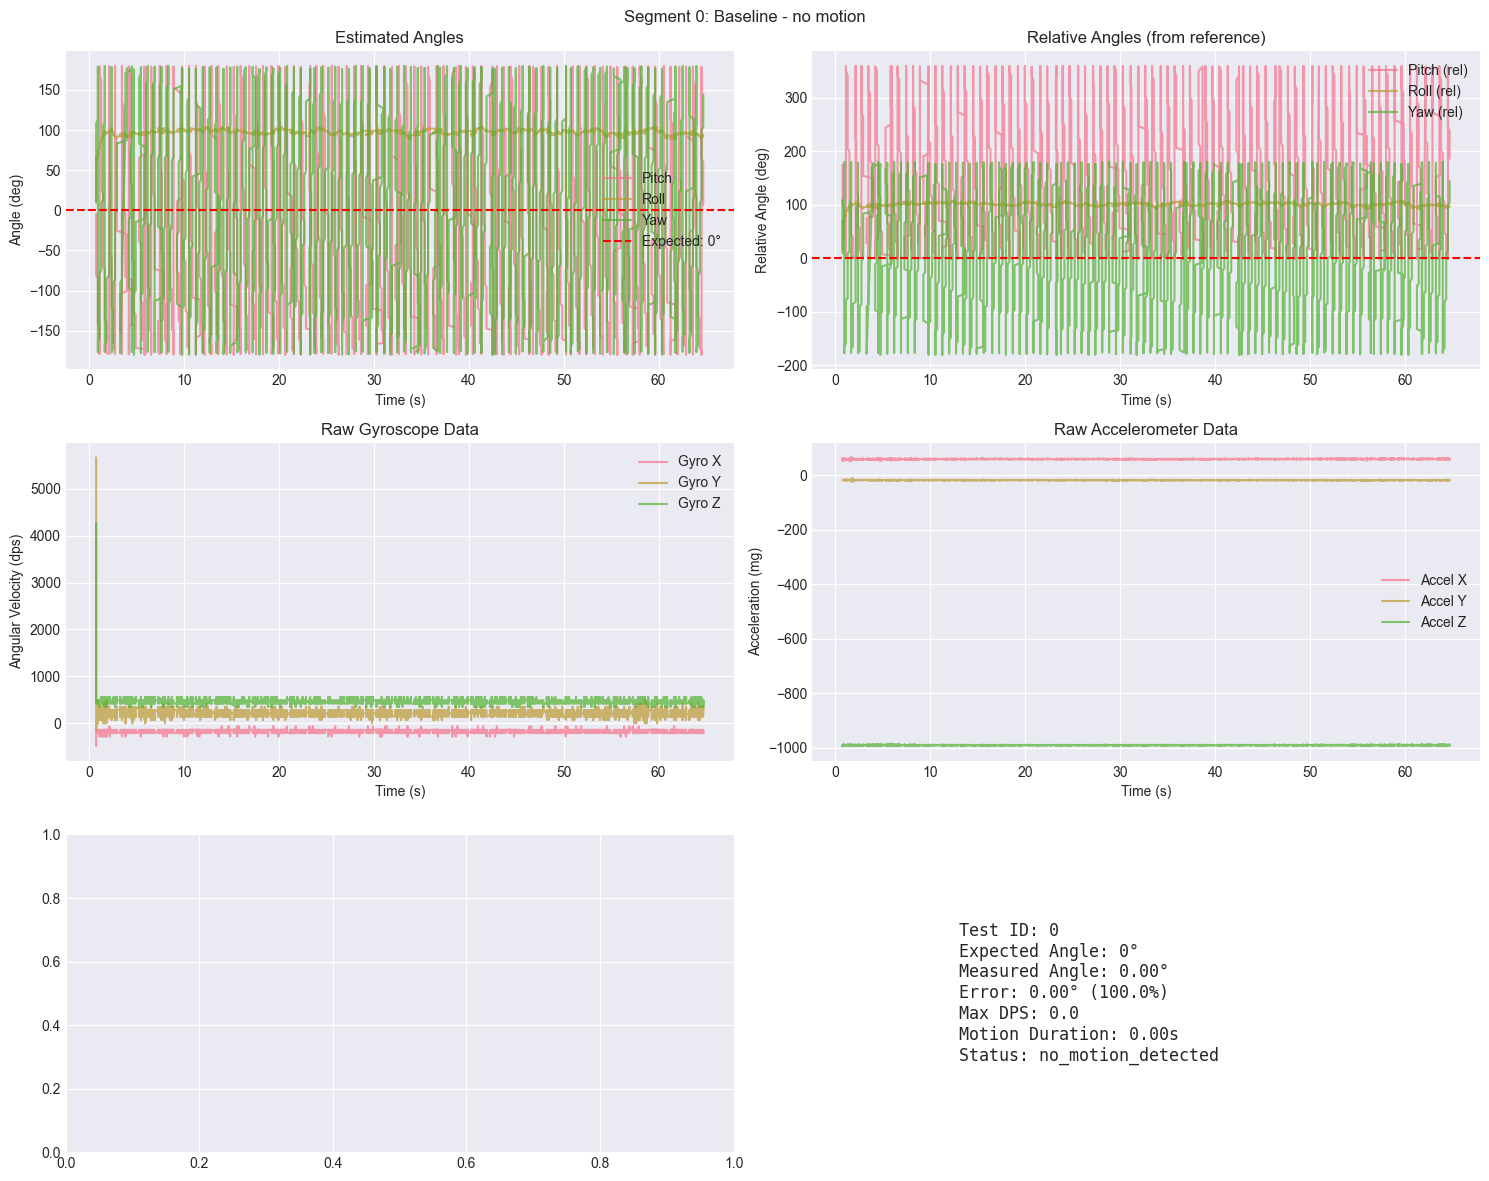


Processing segment 1: Pitch up 45°
  No motion detected in segment 1
  No motion detected in segment 1


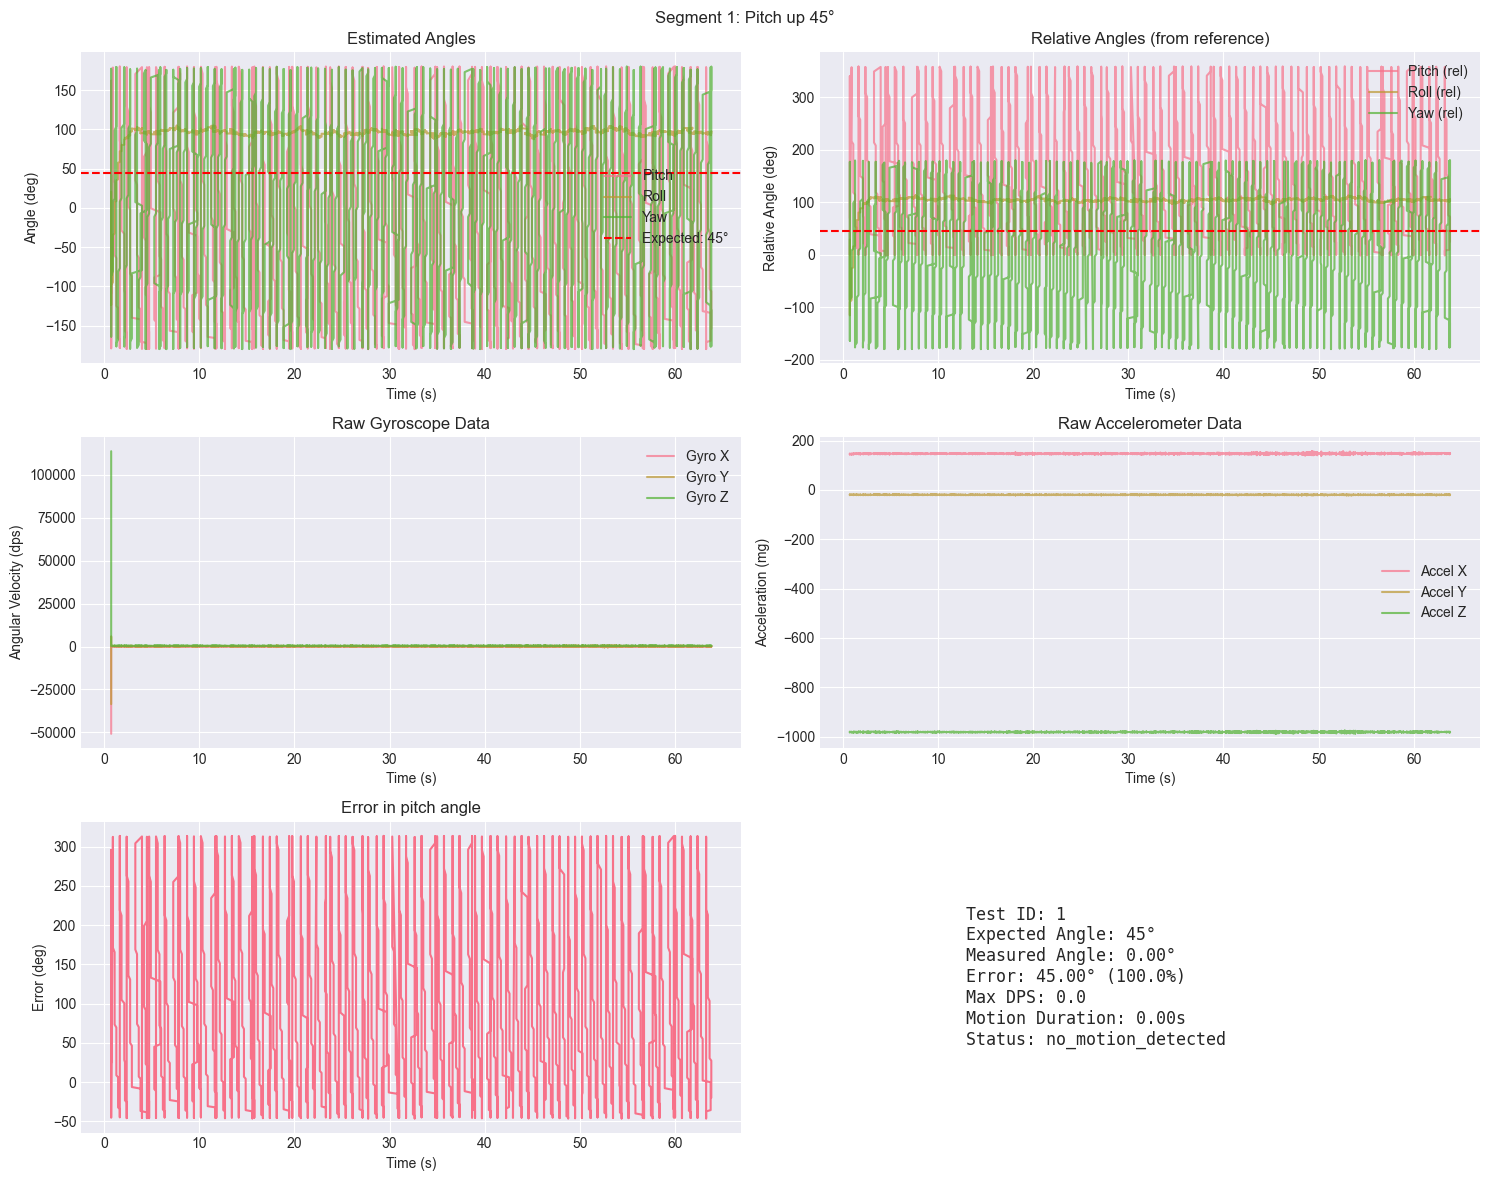


Processing segment 2: Pitch up 40°
  No motion detected in segment 2
  No motion detected in segment 2


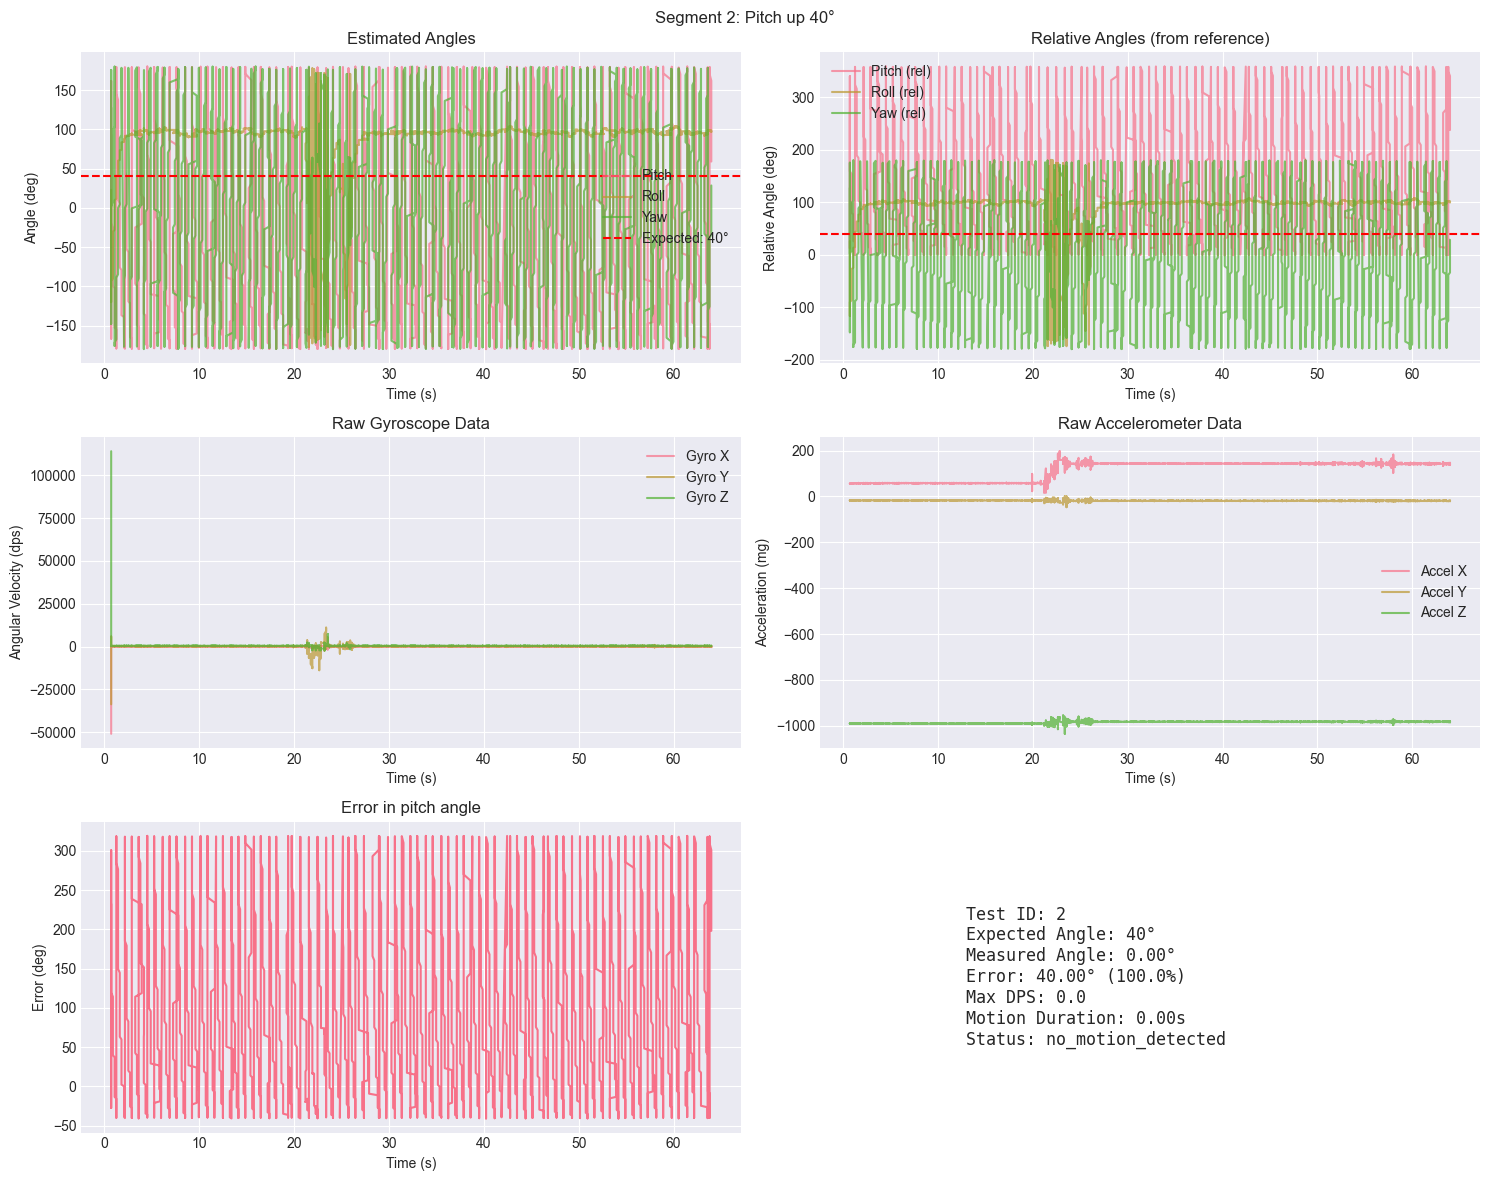


=== Real Data Results Summary ===
   test_id           description  expected_angle  measured_angle  error_deg  error_percent
0        0  Baseline - no motion               0               0          0            100
1        1          Pitch up 45°              45               0         45            100
2        2          Pitch up 40°              40               0         40            100


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
from scipy import signal
from motion_estimator import MotionEstimator
import json

class RealDataProcessor:
    """Process and validate real IMU data against known test conditions"""
    
    def __init__(self):
        self.segments = []
        self.test_definitions = {}
        
    def load_test_definitions(self, filepath: str = None):
        """Load or define test scenarios for real data"""
        # Default test definitions matching your setup
        self.test_definitions = {
            0: {"angle": 0, "axis": "none", "description": "Baseline - no motion"},
            1: {"angle": 45, "axis": "pitch", "description": "Pitch up 45°"},
            2: {"angle": 40, "axis": "pitch", "description": "Pitch up 40°"},
            3: {"angle": 30, "axis": "pitch", "description": "Pitch up 30°"},
            4: {"angle": 20, "axis": "pitch", "description": "Pitch up 20°"},
            5: {"angle": 10, "axis": "pitch", "description": "Pitch up 10°"},
            6: {"angle": 5, "axis": "pitch", "description": "Pitch up 5°"},
            7: {"angle": 4, "axis": "pitch", "description": "Pitch up 4°"},
            8: {"angle": 3, "axis": "pitch", "description": "Pitch up 3°"},
            9: {"angle": 2, "axis": "pitch", "description": "Pitch up 2°"},
            10: {"angle": 1, "axis": "pitch", "description": "Pitch up 1°"},
            11: {"angle": 0.5, "axis": "pitch", "description": "Pitch up 0.5°"},
        }
        
        if filepath:
            with open(filepath, 'r') as f:
                self.test_definitions = json.load(f)
    
    def segment_data(self, df: pd.DataFrame, gap_threshold: float = 5.0) -> List[Dict]:
        """Segment data based on time gaps"""
        timestamps = df["timestamp"].values
        gaps = np.where(np.abs(np.diff(timestamps)) > gap_threshold)[0]
        
        # Create segment boundaries
        segment_bounds = []
        start = 0
        for gap_idx in gaps:
            segment_bounds.append((start, gap_idx + 1))
            start = gap_idx + 1
        segment_bounds.append((start, len(df)))
        
        print(f"Found {len(segment_bounds)} segments:")
        segments = []
        for i, (start, end) in enumerate(segment_bounds):
            duration = df.iloc[end-1]['timestamp'] - df.iloc[start]['timestamp']
            print(f"  Segment {i}: samples {start}-{end-1}, duration {duration:.1f}s")
            
            segment_data = df.iloc[start:end].copy()
            test_info = self.test_definitions.get(i, {
                "angle": 0, "axis": "unknown", "description": f"Segment {i}"
            })
            
            segments.append({
                'test_id': i,
                'data': segment_data.reset_index(drop=True),
                'start_idx': start,
                'end_idx': end,
                'duration': duration,
                'expected_angle': test_info['angle'],
                'axis': test_info['axis'],
                'description': test_info['description']
            })
        
        self.segments = segments
        return segments
    
    def convert_edn_to_ned(self, df: pd.DataFrame) -> pd.DataFrame:
        """Convert from EDN to NED coordinate system"""
        df = df.copy()
        
        # Store original for reference
        df['accel_x_edn'] = df['accel_x']
        df['accel_y_edn'] = df['accel_y']
        df['accel_z_edn'] = df['accel_z']
        
        # EDN to NED transformation
        accel_x_ned = df["accel_z"].copy()   # North (Z_EDN -> X_NED)
        accel_y_ned = df["accel_x"].copy()   # East (X_EDN -> Y_NED)
        accel_z_ned = -df["accel_y"].copy()  # Down (Y_EDN -> -Z_NED)
        
        df["accel_x"] = accel_x_ned
        df["accel_y"] = accel_y_ned
        df["accel_z"] = accel_z_ned
        
        # Same for gyro
        gyro_x_ned = df["gyro_z"].copy()
        gyro_y_ned = df["gyro_x"].copy()
        gyro_z_ned = -df["gyro_y"].copy()
        
        df["gyro_x"] = gyro_x_ned
        df["gyro_y"] = gyro_y_ned
        df["gyro_z"] = gyro_z_ned
        
        return df
    
    def detect_motion_events(self, segment: Dict, threshold_dps: float = 2.0) -> List[Dict]:
        """Detect motion start/stop events in a segment"""
        data = segment['data']
        
        # Calculate magnitude of angular velocity
        gyro_mag = np.sqrt(data['gyro_x']**2 + data['gyro_y']**2 + data['gyro_z']**2)
        
        # Apply moving average for noise reduction
        window = min(10, len(gyro_mag) // 10)
        if window > 1:
            gyro_mag_smooth = signal.savgol_filter(gyro_mag, window, 3)
        else:
            gyro_mag_smooth = gyro_mag
        
        # Detect motion periods
        in_motion = gyro_mag_smooth > threshold_dps
        motion_changes = np.diff(np.concatenate([[False], in_motion, [False]]))
        starts = np.where(motion_changes == 1)[0]
        stops = np.where(motion_changes == -1)[0]
        
        events = []
        for start, stop in zip(starts, stops):
            if stop - start > 10:  # At least 10 samples
                events.append({
                    'start_idx': start,
                    'stop_idx': stop,
                    'duration_s': (data.iloc[stop]['timestamp'] - data.iloc[start]['timestamp']),
                    'start_time': data.iloc[start]['timestamp'],
                    'stop_time': data.iloc[stop]['timestamp']
                })
        
        return events
    
    def calculate_reference_angle(self, segment: Dict, 
                                 start_samples: int = 104) -> Dict[str, float]:
        """Calculate reference angles from initial static period"""
        data = segment['data']
        
        if len(data) < start_samples:
            start_samples = len(data) // 4
        
        ref_data = data.iloc[:start_samples]
        
        # Calculate mean accelerometer angles
        accel_x_mean = ref_data['accel_x'].mean()
        accel_y_mean = ref_data['accel_y'].mean()
        accel_z_mean = ref_data['accel_z'].mean()
        
        # Convert from mg to m/s²
        ax = accel_x_mean * 9.80665 / 1000
        ay = accel_y_mean * 9.80665 / 1000
        az = accel_z_mean * 9.80665 / 1000
        
        # Calculate reference angles
        pitch_ref = np.rad2deg(np.arctan2(ay, az))
        roll_ref = np.rad2deg(np.arctan2(-ax, np.sqrt(ay**2 + az**2)))
        
        return {
            'pitch': pitch_ref,
            'roll': roll_ref,
            'yaw': 0  # Yaw has no absolute reference from accel
        }
    
    def process_segment(self, segment: Dict, estimator: Optional[MotionEstimator] = None) -> pd.DataFrame:
        """Process a single segment through the motion estimator"""
        if estimator is None:
            estimator = MotionEstimator()
        
        data = segment['data']
        outputs = []
        
        # Get reference angles
        ref_angles = self.calculate_reference_angle(segment)
        
        # Process each sample
        for i, row in data.iterrows():
            accel_raw = [row["accel_x"], row["accel_y"], row["accel_z"]]
            gyro_raw = [row["gyro_x"], row["gyro_y"], row["gyro_z"]]
            ts = row["timestamp"]
            
            output = estimator.update(accel_raw, gyro_raw, ts)
            
            # Add segment info
            output['test_id'] = segment['test_id']
            output['expected_angle'] = segment['expected_angle']
            output['axis'] = segment['axis']
            output['sample_idx'] = i
            
            # Add reference-relative angles
            output['pitch_relative'] = output['pitch_deg'] - ref_angles['pitch']
            output['roll_relative'] = output['roll_deg'] - ref_angles['roll']
            output['yaw_relative'] = output['yaw_deg'] - ref_angles['yaw']
            
            outputs.append(output)
        
        return pd.DataFrame(outputs)
    
    def analyze_segment_accuracy(self, processed_df: pd.DataFrame, segment: Dict) -> Dict:
        """Analyze accuracy of motion estimation for a segment"""
        
        # Detect motion events
        motion_events = self.detect_motion_events(segment)

        
        if not motion_events:
            print(f"  No motion detected in segment {segment['test_id']}")
            return {
                'test_id': segment['test_id'],
                'expected_angle': segment['expected_angle'],
                'measured_angle': 0,
                'error': segment['expected_angle'],
                'error_deg': segment['expected_angle'],
                'error_percent': 100,
                'max_dps': 0,
                'motion_duration': 0,
                'status': 'no_motion_detected'
            }
        
        # Get the primary motion event (usually the first major one)
        main_event = motion_events[0]
        
        # Measure angle at end of motion
        axis_key = f"{segment['axis']}_relative"
        if axis_key not in processed_df.columns:
            axis_key = f"{segment['axis']}_deg"
        
        # Get angle after motion stabilizes
        stabilize_idx = min(main_event['stop_idx'] + 20, len(processed_df) - 1)
        measured_angle = processed_df.iloc[stabilize_idx][axis_key]
        
        # Calculate error
        error = abs(measured_angle - segment['expected_angle'])
        error_percent = (error / max(segment['expected_angle'], 0.1)) * 100
        
        # Calculate max DPS during motion
        motion_data = processed_df.iloc[main_event['start_idx']:main_event['stop_idx']]
        if segment['axis'] == 'pitch':
            gyro_col = 'gyro_x'
        elif segment['axis'] == 'roll':
            gyro_col = 'gyro_y'
        else:
            gyro_col = 'gyro_z'
        
        max_dps = segment['data'][gyro_col].iloc[
            main_event['start_idx']:main_event['stop_idx']
        ].abs().max()
        
        return {
            'test_id': segment['test_id'],
            'description': segment['description'],
            'expected_angle': segment['expected_angle'],
            'measured_angle': measured_angle,
            'error_deg': error,
            'error_percent': error_percent,
            'max_dps': max_dps,
            'motion_duration': main_event['duration_s'],
            'status': 'analyzed'
        }
    
    def visualize_segment(self, segment: Dict, processed_df: pd.DataFrame):
        """Visualize a single segment's data and results"""
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle(f"Segment {segment['test_id']}: {segment['description']}")
        
        time = processed_df['timestamp'].values
        
        # Plot angles
        axes[0, 0].plot(time, processed_df['pitch_deg'], label='Pitch', alpha=0.7)
        axes[0, 0].plot(time, processed_df['roll_deg'], label='Roll', alpha=0.7)
        axes[0, 0].plot(time, processed_df['yaw_deg'], label='Yaw', alpha=0.7)
        axes[0, 0].axhline(segment['expected_angle'], color='red', linestyle='--', 
                          label=f'Expected: {segment["expected_angle"]}°')
        axes[0, 0].set_ylabel('Angle (deg)')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_title('Estimated Angles')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # Plot relative angles
        axes[0, 1].plot(time, processed_df['pitch_relative'], label='Pitch (rel)', alpha=0.7)
        axes[0, 1].plot(time, processed_df['roll_relative'], label='Roll (rel)', alpha=0.7)
        axes[0, 1].plot(time, processed_df['yaw_relative'], label='Yaw (rel)', alpha=0.7)
        axes[0, 1].axhline(segment['expected_angle'], color='red', linestyle='--')
        axes[0, 1].set_ylabel('Relative Angle (deg)')
        axes[0, 1].set_xlabel('Time (s)')
        axes[0, 1].set_title('Relative Angles (from reference)')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # Plot gyro data
        data = segment['data']
        axes[1, 0].plot(data['timestamp'], data['gyro_x'], label='Gyro X', alpha=0.7)
        axes[1, 0].plot(data['timestamp'], data['gyro_y'], label='Gyro Y', alpha=0.7)
        axes[1, 0].plot(data['timestamp'], data['gyro_z'], label='Gyro Z', alpha=0.7)
        axes[1, 0].set_ylabel('Angular Velocity (dps)')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_title('Raw Gyroscope Data')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # Plot accel data
        axes[1, 1].plot(data['timestamp'], data['accel_x'], label='Accel X', alpha=0.7)
        axes[1, 1].plot(data['timestamp'], data['accel_y'], label='Accel Y', alpha=0.7)
        axes[1, 1].plot(data['timestamp'], data['accel_z'], label='Accel Z', alpha=0.7)
        axes[1, 1].set_ylabel('Acceleration (mg)')
        axes[1, 1].set_xlabel('Time (s)')
        axes[1, 1].set_title('Raw Accelerometer Data')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
        
        # Detect and plot motion events
        motion_events = self.detect_motion_events(segment)
        for event in motion_events:
            for ax in [axes[0, 0], axes[0, 1]]:
                ax.axvspan(event['start_time'], event['stop_time'], 
                          alpha=0.2, color='yellow', label='Motion')
        
        # Plot error over time
        axis_key = f"{segment['axis']}_relative"
        if axis_key in processed_df.columns:
            error = processed_df[axis_key] - segment['expected_angle']
            axes[2, 0].plot(time, error)
            axes[2, 0].set_ylabel('Error (deg)')
            axes[2, 0].set_xlabel('Time (s)')
            axes[2, 0].set_title(f'Error in {segment["axis"]} angle')
            axes[2, 0].grid(True)
        
        # Summary statistics
        axes[2, 1].axis('off')
        accuracy = self.analyze_segment_accuracy(processed_df, segment)
        summary_text = f"""
        Test ID: {accuracy['test_id']}
        Expected Angle: {accuracy['expected_angle']}°
        Measured Angle: {accuracy['measured_angle']:.2f}°
        Error: {accuracy['error_deg']:.2f}° ({accuracy['error_percent']:.1f}%)
        Max DPS: {accuracy['max_dps']:.1f}
        Motion Duration: {accuracy['motion_duration']:.2f}s
        Status: {accuracy['status']}
        """
        axes[2, 1].text(0.1, 0.5, summary_text, fontsize=12, 
                       verticalalignment='center', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()

class ComparisonAnalyzer:
    """Compare real data results with synthetic test results"""
    
    def __init__(self):
        self.real_results = []
        self.synthetic_results = []
    
    def compare_results(self, real_df: pd.DataFrame, synthetic_df: pd.DataFrame):
        """Compare real and synthetic test results"""
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Group by similar angle ranges
        angle_bins = [0, 1, 2, 5, 10, 20, 30, 45, 90]
        
        # Bin both datasets
        real_df['angle_bin'] = pd.cut(real_df['expected_angle'], bins=angle_bins)
        synthetic_df['angle_bin'] = pd.cut(synthetic_df['angle_magnitude'], bins=angle_bins)
        
        # Compare error distributions
        ax = axes[0, 0]
        real_errors = real_df.groupby('angle_bin')['error_deg'].mean()
        synthetic_errors = synthetic_df.groupby('angle_bin')['rmse'].mean()
        
        x = np.arange(len(real_errors))
        width = 0.35
        ax.bar(x - width/2, real_errors, width, label='Real Data', alpha=0.7)
        ax.bar(x + width/2, synthetic_errors, width, label='Synthetic', alpha=0.7)
        ax.set_xlabel('Angle Range')
        ax.set_ylabel('Mean Error (degrees)')
        ax.set_title('Error Comparison by Angle Range')
        ax.set_xticks(x)
        ax.set_xticklabels([str(b) for b in real_errors.index], rotation=45)
        ax.legend()
        ax.grid(True)
        
        # Compare error vs DPS
        ax = axes[0, 1]
        ax.scatter(real_df['max_dps'], real_df['error_deg'], 
                  label='Real', alpha=0.6, s=50)
        ax.scatter(synthetic_df['max_dps'], synthetic_df['rmse'], 
                  label='Synthetic', alpha=0.6, s=30)
        ax.set_xlabel('Max DPS')
        ax.set_ylabel('Error (degrees)')
        ax.set_title('Error vs Angular Velocity')
        ax.legend()
        ax.grid(True)
        
        # Distribution comparison
        ax = axes[1, 0]
        ax.hist(real_df['error_percent'], bins=20, alpha=0.5, 
               label='Real', color='blue', density=True)
        # Convert synthetic to percent
        synthetic_error_pct = (synthetic_df['rmse'] / synthetic_df['angle_magnitude']) * 100
        ax.hist(synthetic_error_pct, bins=20, alpha=0.5, 
               label='Synthetic', color='orange', density=True)
        ax.set_xlabel('Error (%)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution Comparison')
        ax.legend()
        ax.grid(True)
        
        # Summary statistics
        ax = axes[1, 1]
        ax.axis('off')
        
        real_stats = f"""Real Data Statistics:
        Mean Error: {real_df['error_deg'].mean():.2f}°
        Std Error: {real_df['error_deg'].std():.2f}°
        Max Error: {real_df['error_deg'].max():.2f}°
        Mean Error %: {real_df['error_percent'].mean():.1f}%
        
        Synthetic Data Statistics:
        Mean RMSE: {synthetic_df['rmse'].mean():.2f}°
        Std RMSE: {synthetic_df['rmse'].std():.2f}°
        Max RMSE: {synthetic_df['rmse'].max():.2f}°
        """
        
        ax.text(0.1, 0.5, real_stats, fontsize=10, 
               verticalalignment='center', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()

# Example usage
if __name__ == "__main__":
    # Load and process real data
    processor = RealDataProcessor()
    processor.load_test_definitions()  # Uses default definitions
    
    # Read CSV
    df = pd.read_csv("raw_data_output_altitude.csv")
    
    # Validate columns
    required_cols = ["timestamp", "accel_x", "accel_y", "accel_z", 
                     "gyro_x", "gyro_y", "gyro_z"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")
    
    # Convert to numeric and clean
    for col in required_cols[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=required_cols)
    
    # Convert coordinate system
    df = processor.convert_edn_to_ned(df)
    
    # Segment data
    segments = processor.segment_data(df)
    
    # Process segments
    all_results = []
    estimator = MotionEstimator()
    
    for segment in segments[:3]:  # Process first 3 segments as example
        print(f"\nProcessing segment {segment['test_id']}: {segment['description']}")
        
        # Process through estimator
        processed_df = processor.process_segment(segment, estimator)
        
        # Analyze accuracy
        accuracy = processor.analyze_segment_accuracy(processed_df, segment)
        accuracy['description'] = segment['description']
        all_results.append(accuracy)
        # Visualize
        processor.visualize_segment(segment, processed_df)
    
    # Create summary DataFrame
    results_df = pd.DataFrame(all_results)
    print("\n=== Real Data Results Summary ===")
    print(results_df[['test_id', 'description', 'expected_angle', 
                      'measured_angle', 'error_deg', 'error_percent']].to_string())